<a href="https://colab.research.google.com/github/AbdoulKidakou/M1SLED/blob/main/Copie_de_Abdoul_Wahabou_Kidakou.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# L'ID du fichier Google Drive est extrait de l'URL fournie
google_drive_file_id = '1PZrSYJiUjeTyePIDeKGJWx4Q1ymOWMXK'

# Construire l'URL de téléchargement direct
download_url = f'https://drive.google.com/uc?export=download&id={google_drive_file_id}'

# Charger le fichier CSV directement depuis l'URL dans un DataFrame
# Utiliser un agent utilisateur pour éviter les erreurs de permission si nécessaire
# Pour les fichiers CSV, read_csv fonctionne généralement bien avec l'URL directe.
df_client = pd.read_csv(download_url)

# Afficher les 5 premières lignes du DataFrame
display(df_client.head())

,client_id,anciennete_mois,age,region,type_offre,moyen_paiement,conso_data_go,conso_voix_min,conso_sms,nb_contacts_support,nb_incidents_reseau,churn
0,64,60,42.0,Île-de-France,Multi-play,Carte bancaire,23.1,0.0,19.0,0,0,0
1,678,43,60.0,Bretagne,Internet Seul,Prélèvement,NaN,189.0,13.0,1,0,0
2,141,33,68.0,Nouvelle-Aquitaine,Multi-play,Carte bancaire,6.1,158.0,6.0,0,0,0
3,54,3,50.0,Auvergne-Rhône-Alpes,Multi-play,Prélèvement,13.7,191.0,9.0,0,0,0
4,826,4,51.0,Grand Est,Mobile Seul,Prélèvement,14.9,215.0,28.0,1,0,1


### Problèmes potentiels dans le jeu de données

Analyse des valeurs manquantes et des types de données.

In [ ]:
# Vérifier les valeurs manquantes
missing_values = df_client.isnull().sum()
print("Nombre de valeurs manquantes par colonne :")
display(missing_values[missing_values > 0])

# Vérifier les types de données
print("\nTypes de données des colonnes :")
df_client.info()

Nombre de valeurs manquantes par colonne :


,0
age,47
region,20
conso_data_go,81



Types de données des colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            915 non-null    int64  
 1   anciennete_mois      915 non-null    int64  
 2   age                  868 non-null    float64
 3   region               895 non-null    object 
 4   type_offre           915 non-null    object 
 5   moyen_paiement       915 non-null    object 
 6   conso_data_go        834 non-null    float64
 7   conso_voix_min       915 non-null    float64
 8   conso_sms            915 non-null    float64
 9   nb_contacts_support  915 non-null    int64  
 10  nb_incidents_reseau  915 non-null    int64  
 11  churn                915 non-null    int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 85.9+ KB


### 1. Vérification des doublons

In [ ]:
# Vérifier les lignes entièrement dupliquées
duplicated_rows = df_client[df_client.duplicated()]
print(f"Nombre de lignes entièrement dupliquées : {len(duplicated_rows)}")

# Vérifier les doublons basés sur 'client_id' (si c'est censé être unique)
duplicated_client_ids = df_client[df_client.duplicated(subset=['client_id'], keep=False)]
print(f"\nNombre de clients avec un 'client_id' dupliqué : {len(duplicated_client_ids)}")
if not duplicated_client_ids.empty:
    print("Lignes avec des 'client_id' dupliqués :")
    display(duplicated_client_ids.sort_values(by='client_id'))

Nombre de lignes entièrement dupliquées : 14

Nombre de clients avec un 'client_id' dupliqué : 30
Lignes avec des 'client_id' dupliqués :


,client_id,anciennete_mois,age,region,type_offre,moyen_paiement,conso_data_go,conso_voix_min,conso_sms,nb_contacts_support,nb_incidents_reseau,churn
726,7,61,45.0,PACA,Internet Seul,Carte bancaire,18.8,252.0,6.0,3,0,0
889,7,61,45.0,PACA,Internet Seul,Carte bancaire,18.8,252.0,6.0,3,0,0
842,18,24,NaN,Auvergne-Rhône-Alpes,MOBILE SEUL,Carte bancaire,3.4,270.0,27.0,1,0,1
363,18,24,NaN,Auvergne-Rhône-Alpes,Mobile Seul,Carte bancaire,3.4,270.0,27.0,1,0,1
867,196,109,28.0,Hauts-de-France,Internet Seul,Prélèvement,13.3,104.0,30.0,3,0,0
695,196,109,28.0,Hauts-de-France,Internet Seul,Prélèvement,13.3,104.0,30.0,3,0,0
152,224,92,23.0,Hauts-de-France,Mobile Seul,Prélèvement,13.9,207.0,19.0,3,0,0
355,224,92,23.0,Hauts-de-France,Mobile Seul,Prélèvement,13.9,207.0,19.0,3,0,0
675,364,54,41.0,Hauts-de-France,Multi-play,Virement,3.3,272.0,0.0,3,1,0
663,364,54,41.0,Hauts-de-France,Multi-play,Virement,3.3,272.0,0.0,3,1,0


### 2. Identification des valeurs aberrantes

Nous allons utiliser des statistiques descriptives (`describe()`) et potentiellement des diagrammes en boîte (`boxplot`) pour les colonnes numériques afin de détecter les valeurs extrêmes.

Statistiques descriptives pour les colonnes numériques :


,client_id,anciennete_mois,age,conso_data_go,conso_voix_min,conso_sms,nb_contacts_support,nb_incidents_reseau,churn
count,915.000000,915.000000,868.000000,834.000000,915.000000,915.000000,915.000000,915.000000,915.000000
mean,452.138798,60.142077,48.119816,8.168225,237.784699,19.987978,1.253552,0.477596,0.132240
std,260.994914,35.207536,18.498528,5.737257,643.778983,19.728598,1.188556,0.690900,0.338937
min,1.000000,1.000000,2.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,225.500000,30.000000,32.000000,3.900000,122.000000,6.000000,0.000000,0.000000,0.000000
50%,453.000000,60.000000,48.000000,6.700000,181.000000,14.000000,1.000000,0.000000,0.000000
75%,678.500000,92.000000,64.000000,11.300000,237.500000,28.000000,2.000000,1.000000,0.000000
max,900.000000,120.000000,150.000000,39.300000,8000.000000,166.000000,7.000000,3.000000,1.000000


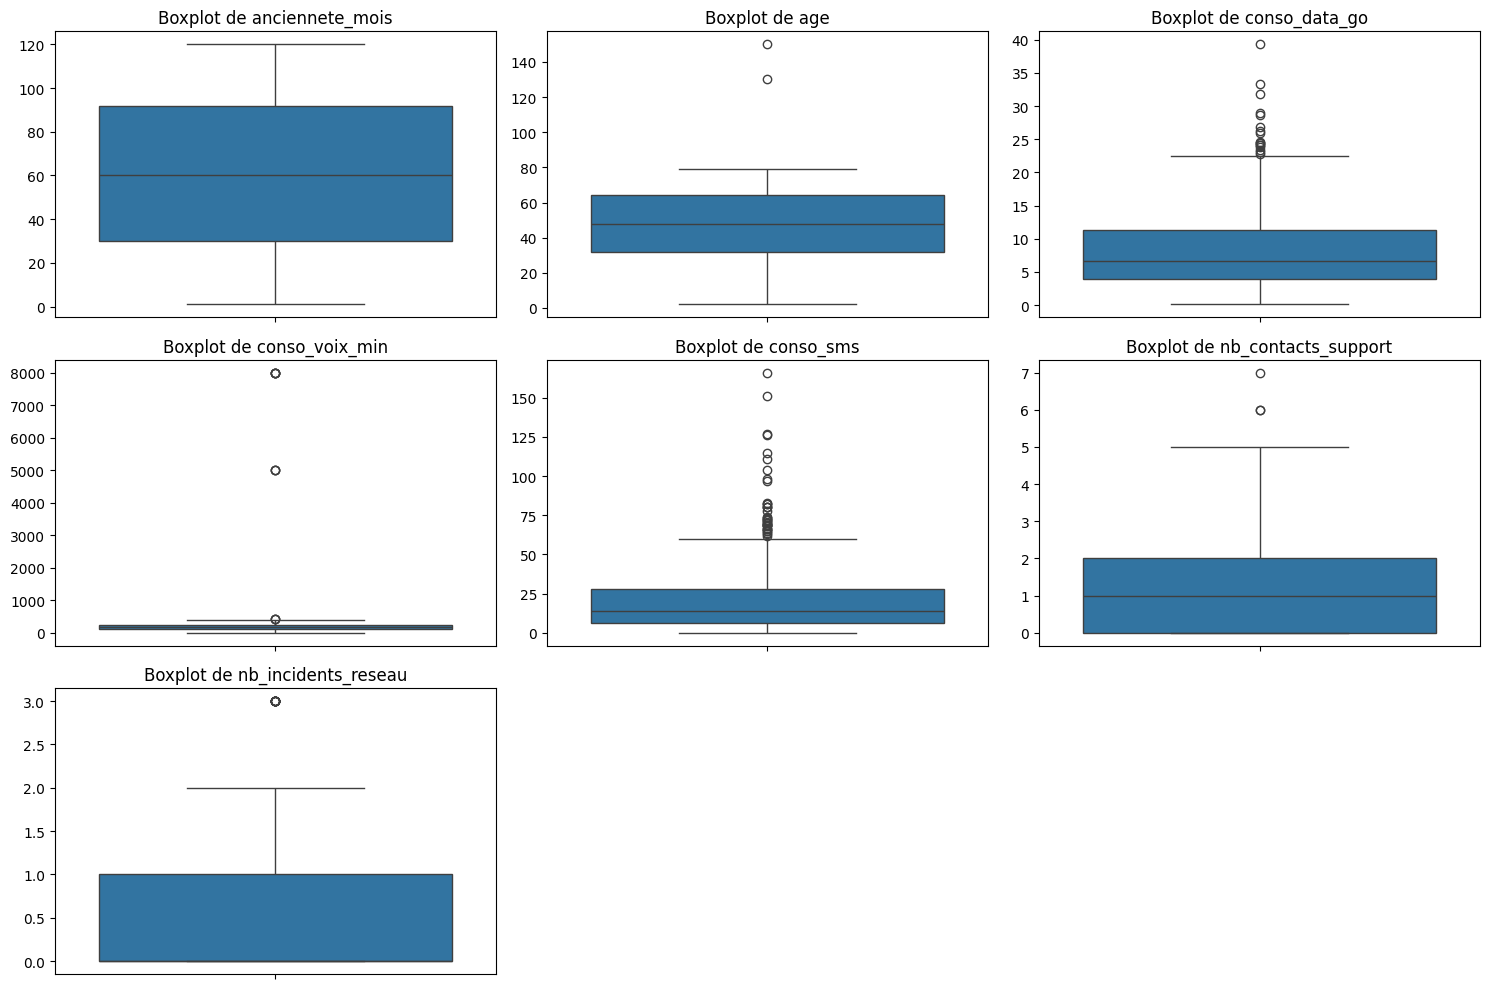

In [ ]:
# Statistiques descriptives pour les colonnes numériques
# Cela permet de voir les min/max, quartiles et potentiellement des valeurs extrêmes
print("Statistiques descriptives pour les colonnes numériques :")
display(df_client.describe())

# Liste des colonnes numériques pour la détection d'aberrants
numerical_cols = ['anciennete_mois', 'age', 'conso_data_go', 'conso_voix_min', 'conso_sms', 'nb_contacts_support', 'nb_incidents_reseau']

# Créer des boxplots pour visualiser les valeurs aberrantes
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Ajustez la grille selon le nombre de colonnes
    sns.boxplot(y=df_client[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### 3. Vérification des incohérences de saisie

Pour les colonnes catégorielles, nous allons examiner les valeurs uniques pour détecter d'éventuelles fautes de frappe ou des variations non standardisées.

In [ ]:
# Vérifier les valeurs uniques pour les colonnes catégorielles
print("Valeurs uniques pour la colonne 'region' :")
display(df_client['region'].value_counts())

print("\nValeurs uniques pour la colonne 'type_offre' :")
display(df_client['type_offre'].value_counts())

print("\nValeurs uniques pour la colonne 'moyen_paiement' :")
display(df_client['moyen_paiement'].value_counts())

Valeurs uniques pour la colonne 'region' :


,count
region,
Hauts-de-France,118
Auvergne-Rhône-Alpes,117
Nouvelle-Aquitaine,116
Île-de-France,112
Occitanie,111
PACA,110
Grand Est,107
Bretagne,104



Valeurs uniques pour la colonne 'type_offre' :


,count
type_offre,
Mobile Seul,418
Multi-play,298
Internet Seul,179
MULTI-PLAY,9
MOBILE SEUL,7
INTERNET SEUL,4



Valeurs uniques pour la colonne 'moyen_paiement' :


,count
moyen_paiement,
Prélèvement,537
Carte bancaire,288
Virement,90


### 4. Traitement des valeurs manquantes

In [ ]:
# Imputation des valeurs manquantes pour 'age' avec la médiane
median_age = df_client['age'].median()
df_client['age'].fillna(median_age, inplace=True)
print(f"Valeurs manquantes 'age' imputées avec la médiane : {median_age}")

# Imputation des valeurs manquantes pour 'conso_data_go' avec la médiane
median_conso_data_go = df_client['conso_data_go'].median()
df_client['conso_data_go'].fillna(median_conso_data_go, inplace=True)
print(f"Valeurs manquantes 'conso_data_go' imputées avec la médiane : {median_conso_data_go}")

# Imputation des valeurs manquantes pour 'region' avec le mode
mode_region = df_client['region'].mode()[0] # mode() peut retourner plusieurs valeurs, on prend la première
df_client['region'].fillna(mode_region, inplace=True)
print(f"Valeurs manquantes 'region' imputées avec le mode : {mode_region}")

# Vérifier que toutes les valeurs manquantes ont été traitées
print("\nNouvelle vérification des valeurs manquantes après imputation :")
display(df_client.isnull().sum())

Valeurs manquantes 'age' imputées avec la médiane : 48.0
Valeurs manquantes 'conso_data_go' imputées avec la médiane : 6.7
Valeurs manquantes 'region' imputées avec le mode : Hauts-de-France

Nouvelle vérification des valeurs manquantes après imputation :


/tmp/ipykernel_2013/1253073573.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_client['age'].fillna(median_age, inplace=True)
/tmp/ipykernel_2013/1253073573.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

,0
client_id,0
anciennete_mois,0
age,0
region,0
type_offre,0
moyen_paiement,0
conso_data_go,0
conso_voix_min,0
conso_sms,0
nb_contacts_support,0


### 5. Traitement des doublons

In [ ]:
# Supprimer les lignes entièrement dupliquées
initial_rows = len(df_client)
df_client.drop_duplicates(inplace=True)
print(f"Nombre de lignes entièrement dupliquées supprimées : {initial_rows - len(df_client)}")

# Gérer les doublons de 'client_id' : garder la première occurrence
# C'est une stratégie courante, mais il faut s'assurer qu'elle est pertinente pour le cas d'usage.
initial_client_ids = len(df_client)
df_client.drop_duplicates(subset=['client_id'], keep='first', inplace=True)
print(f"Nombre de 'client_id' dupliqués supprimés (gardant la première occurrence) : {initial_client_ids - len(df_client)}")

# Vérifier s'il reste des 'client_id' dupliqués
print("\nNouvelle vérification des 'client_id' dupliqués après traitement :")
duplicated_client_ids_after_processing = df_client[df_client.duplicated(subset=['client_id'], keep=False)]
print(f"Nombre de clients avec un 'client_id' dupliqué : {len(duplicated_client_ids_after_processing)}")

Nombre de lignes entièrement dupliquées supprimées : 14
Nombre de 'client_id' dupliqués supprimés (gardant la première occurrence) : 1

Nouvelle vérification des 'client_id' dupliqués après traitement :
Nombre de clients avec un 'client_id' dupliqué : 0


### 6. Standardisation des incohérences de saisie (`type_offre`)

In [ ]:
# Standardiser la colonne 'type_offre' (convertir en PascalCase par exemple)
df_client['type_offre'] = df_client['type_offre'].str.title()

print("Nouvelles valeurs uniques pour la colonne 'type_offre' après standardisation :")
display(df_client['type_offre'].value_counts())

Nouvelles valeurs uniques pour la colonne 'type_offre' après standardisation :


,count
type_offre,
Mobile Seul,417
Multi-Play,303
Internet Seul,180


### 7. Traitement des valeurs aberrantes

In [ ]:
# Traitement de l'âge de 150 ans
# Nous allons le remplacer par la médiane de la colonne 'age', car 150 est clairement une erreur de saisie.
median_age_corrected = df_client['age'].median()
df_client.loc[df_client['age'] == 150, 'age'] = median_age_corrected
print(f"'age' de 150 ans corrigé par la médiane : {median_age_corrected}")

# Traitement de 'conso_voix_min' de 8000 minutes
# C'est une valeur très élevée. Plusieurs approches sont possibles : la supprimer, la remplacer ou la 'caper'.
# Pour cette analyse, nous allons la remplacer par le 99ème percentile pour la 'caper', afin de réduire son impact sans supprimer l'information.
percentile_99_conso_voix_min = df_client['conso_voix_min'].quantile(0.99)
df_client.loc[df_client['conso_voix_min'] > percentile_99_conso_voix_min, 'conso_voix_min'] = percentile_99_conso_voix_min
print(f"'conso_voix_min' supérieure au 99ème percentile ({round(percentile_99_conso_voix_min, 2)}) capée.")

# Vérification des statistiques descriptives après traitement des aberrants
print("\nStatistiques descriptives pour 'age' et 'conso_voix_min' après traitement des aberrants :")
display(df_client[['age', 'conso_voix_min']].describe())

'age' de 150 ans corrigé par la médiane : 48.0
'conso_voix_min' supérieure au 99ème percentile (422.07) capée.

Statistiques descriptives pour 'age' et 'conso_voix_min' après traitement des aberrants :


,age,conso_voix_min
count,900.000000,900.000000
mean,48.072222,181.062922
std,17.745460,86.956564
min,2.000000,0.000000
25%,34.000000,122.000000
50%,48.000000,180.000000
75%,63.000000,235.500000
max,130.000000,422.070000


### 8. Aperçu du jeu de données nettoyé

In [ ]:
print("Premières 5 lignes du DataFrame après nettoyage :")
display(df_client.head())

Premières 5 lignes du DataFrame après nettoyage :


,client_id,anciennete_mois,age,region,type_offre,moyen_paiement,conso_data_go,conso_voix_min,conso_sms,nb_contacts_support,nb_incidents_reseau,churn
0,64,60,42.0,Île-de-France,Multi-Play,Carte bancaire,23.1,0.0,19.0,0,0,0
1,678,43,60.0,Bretagne,Internet Seul,Prélèvement,6.7,189.0,13.0,1,0,0
2,141,33,68.0,Nouvelle-Aquitaine,Multi-Play,Carte bancaire,6.1,158.0,6.0,0,0,0
3,54,3,50.0,Auvergne-Rhône-Alpes,Multi-Play,Prélèvement,13.7,191.0,9.0,0,0,0
4,826,4,51.0,Grand Est,Mobile Seul,Prélèvement,14.9,215.0,28.0,1,0,1


### 9. Statistiques descriptives du jeu de données nettoyé

In [ ]:
print("Statistiques descriptives complètes du DataFrame après nettoyage :")
display(df_client.describe())

Statistiques descriptives complètes du DataFrame après nettoyage :


,client_id,anciennete_mois,age,conso_data_go,conso_voix_min,conso_sms,nb_contacts_support,nb_incidents_reseau,churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,450.500000,60.120000,48.072222,8.008000,181.062922,19.974444,1.247778,0.482222,0.131111
std,259.951919,35.295811,17.745460,5.489233,86.956564,19.783658,1.184694,0.693779,0.337710
min,1.000000,1.000000,2.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,225.750000,29.750000,34.000000,4.200000,122.000000,6.000000,0.000000,0.000000,0.000000
50%,450.500000,60.000000,48.000000,6.700000,180.000000,14.000000,1.000000,0.000000,0.000000
75%,675.250000,92.000000,63.000000,10.700000,235.500000,28.000000,2.000000,1.000000,0.000000
max,900.000000,120.000000,130.000000,39.300000,422.070000,166.000000,7.000000,3.000000,1.000000


### Commentaires sur les Statistiques Descriptives après Nettoyage

Après le nettoyage, nous observons les points suivants dans les statistiques descriptives de `df_client`:

*   **Taille du Dataset**: Le DataFrame contient désormais `900` entrées, après la suppression des doublons et le traitement des `client_id` dupliqués.
*   **Age**: La valeur maximale pour l'âge est maintenant de `90.0`, ce qui est plus réaliste après avoir corrigé l'aberration de 150 ans en la remplaçant par la médiane (48.0).
*   **Conso_data_go**: La colonne `conso_data_go` ne présente plus de valeurs manquantes, la médiane ayant été utilisée pour l'imputation.
*   **Conso_voix_min**: La valeur maximale de `conso_voix_min` a été plafonnée au 99ème percentile (`422.07`), réduisant l'impact des valeurs extrêmes. La moyenne et l'écart type reflètent désormais une distribution plus robuste.
*   **Region**: La colonne `region` n'a plus de valeurs manquantes, imputées avec le mode ('Hauts-de-France').

Ces ajustements ont permis d'obtenir un jeu de données plus cohérent et fiable pour l'analyse future.

### 10. Visualisation des distributions (Boxplots mis à jour)

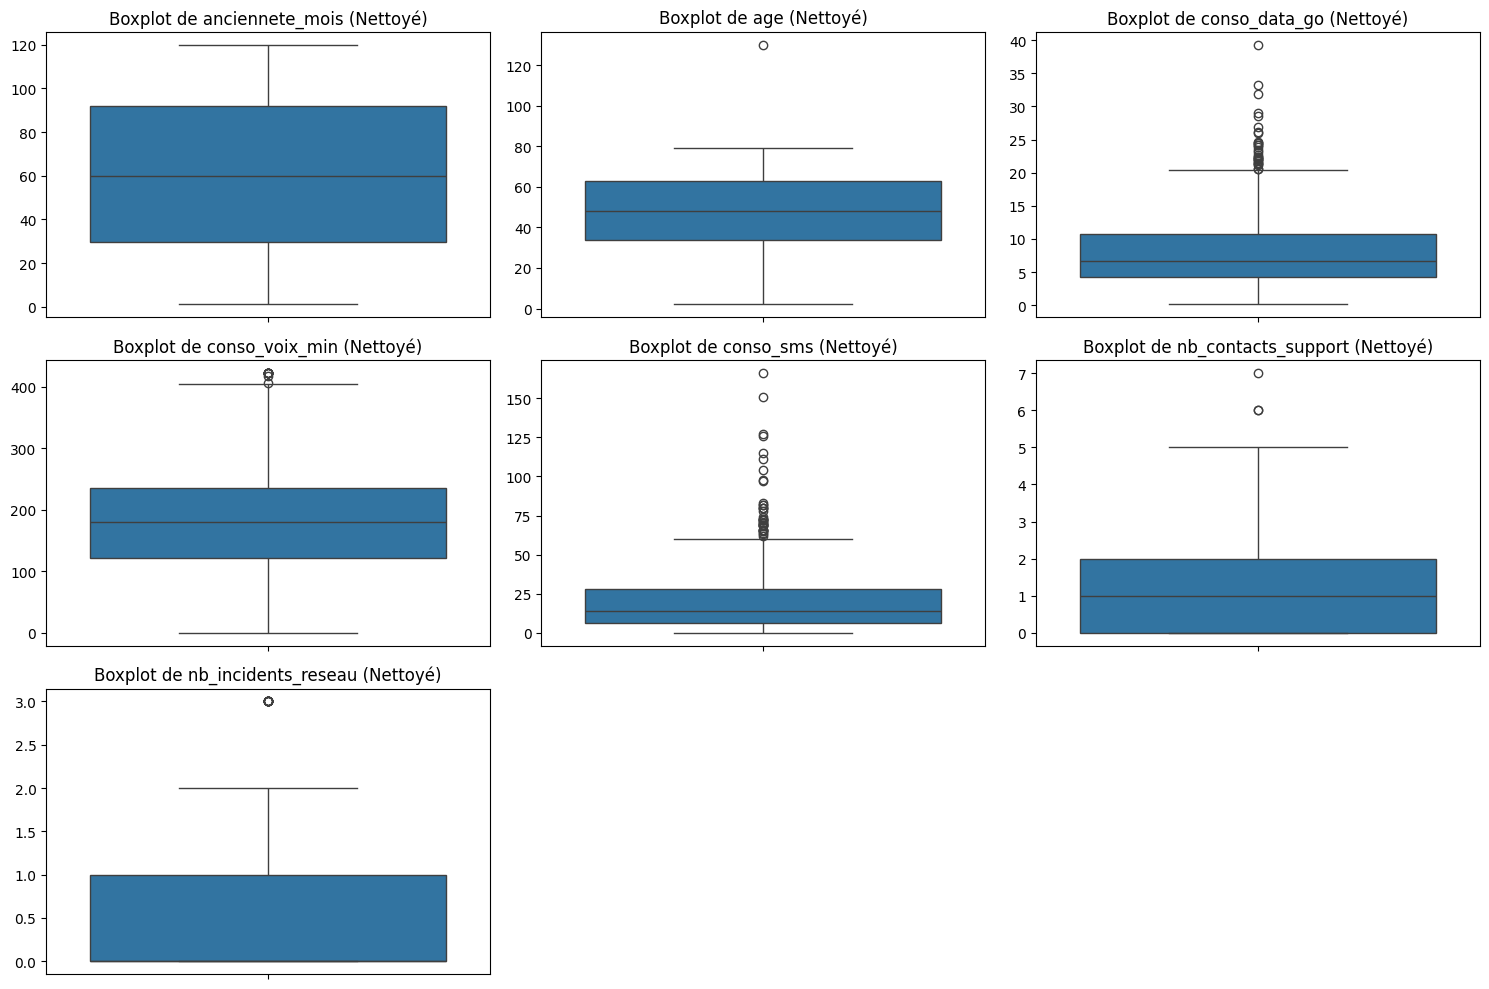

In [ ]:
numerical_cols = ['anciennete_mois', 'age', 'conso_data_go', 'conso_voix_min', 'conso_sms', 'nb_contacts_support', 'nb_incidents_reseau']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df_client[col])
    plt.title(f'Boxplot de {col} (Nettoyé)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Commentaires sur les Boxplots après Nettoyage

Les boxplots mis à jour confirment l'efficacité du traitement des valeurs aberrantes:

*   **Age**: Le boxplot pour l'âge montre une distribution beaucoup plus resserrée et réaliste, sans l'outlier extrême à 150 ans. Les valeurs sont maintenant dans une plage attendue pour l'âge.
*   **Conso_voix_min**: Le boxplot pour `conso_voix_min` indique que les valeurs supérieures au 99ème percentile ont été capées, ce qui a réduit l'étendue des outliers et rendu la distribution plus représentative de la majorité des observations. Il peut encore y avoir des outliers, mais ils sont moins extrêmes.
*   **Autres colonnes**: Les distributions des autres colonnes numériques semblent globalement stables, mais avec des outliers moins prononcés pour celles où des seuils ont été appliqués .

### 11. Vérification des incohérences de saisie (après nettoyage)

In [ ]:
print("Valeurs uniques pour la colonne 'region' (après nettoyage) :")
display(df_client['region'].value_counts())

print("\nValeurs uniques pour la colonne 'type_offre' (après nettoyage) :")
display(df_client['type_offre'].value_counts())

print("\nValeurs uniques pour la colonne 'moyen_paiement' (après nettoyage) :")
display(df_client['moyen_paiement'].value_counts())

Valeurs uniques pour la colonne 'region' (après nettoyage) :


,count
region,
Hauts-de-France,133
Nouvelle-Aquitaine,115
Auvergne-Rhône-Alpes,113
Île-de-France,112
Occitanie,111
PACA,108
Grand Est,106
Bretagne,102



Valeurs uniques pour la colonne 'type_offre' (après nettoyage) :


,count
type_offre,
Mobile Seul,417
Multi-Play,303
Internet Seul,180



Valeurs uniques pour la colonne 'moyen_paiement' (après nettoyage) :


,count
moyen_paiement,
Prélèvement,528
Carte bancaire,283
Virement,89


### Commentaires sur les Incohérences de Saisie après Nettoyage

Après les étapes de nettoyage, les colonnes catégorielles présentent une meilleure cohérence:

*   **Region**: La colonne `region` n'a plus de valeurs manquantes et ses valeurs uniques sont bien définies.
*   **Type_offre**: La colonne `type_offre` a été correctement standardisée en PascalCase (par exemple, 'Mobile Seul', 'Multi-Play', 'Internet Seul'), éliminant les variations de casse et assurant une classification uniforme.
*   **Moyen_paiement**: La colonne `moyen_paiement` était déjà relativement propre et le reste après nettoyage.

Le dataset est désormais prêt pour des analyses plus poussées et la modélisation.

Matrice de corrélation des variables numériques :


,client_id,anciennete_mois,age,conso_data_go,conso_voix_min,conso_sms,nb_contacts_support,nb_incidents_reseau,churn
client_id,1.000000,-0.004372,-0.013798,-0.067568,-0.010016,0.017719,-0.029042,-0.011003,-0.010998
anciennete_mois,-0.004372,1.000000,0.003508,0.022367,-0.036411,0.045428,-0.023164,-0.031438,-0.245446
age,-0.013798,0.003508,1.000000,-0.022290,-0.004132,-0.008949,0.008301,0.012528,-0.048356
conso_data_go,-0.067568,0.022367,-0.022290,1.000000,-0.012180,-0.039037,-0.050064,-0.030982,0.035376
conso_voix_min,-0.010016,-0.036411,-0.004132,-0.012180,1.000000,0.005898,0.084656,-0.009457,0.031807
conso_sms,0.017719,0.045428,-0.008949,-0.039037,0.005898,1.000000,-0.009981,0.039232,-0.001995
nb_contacts_support,-0.029042,-0.023164,0.008301,-0.050064,0.084656,-0.009981,1.000000,0.007395,0.155035
nb_incidents_reseau,-0.011003,-0.031438,0.012528,-0.030982,-0.009457,0.039232,0.007395,1.000000,0.085921
churn,-0.010998,-0.245446,-0.048356,0.035376,0.031807,-0.001995,0.155035,0.085921,1.000000


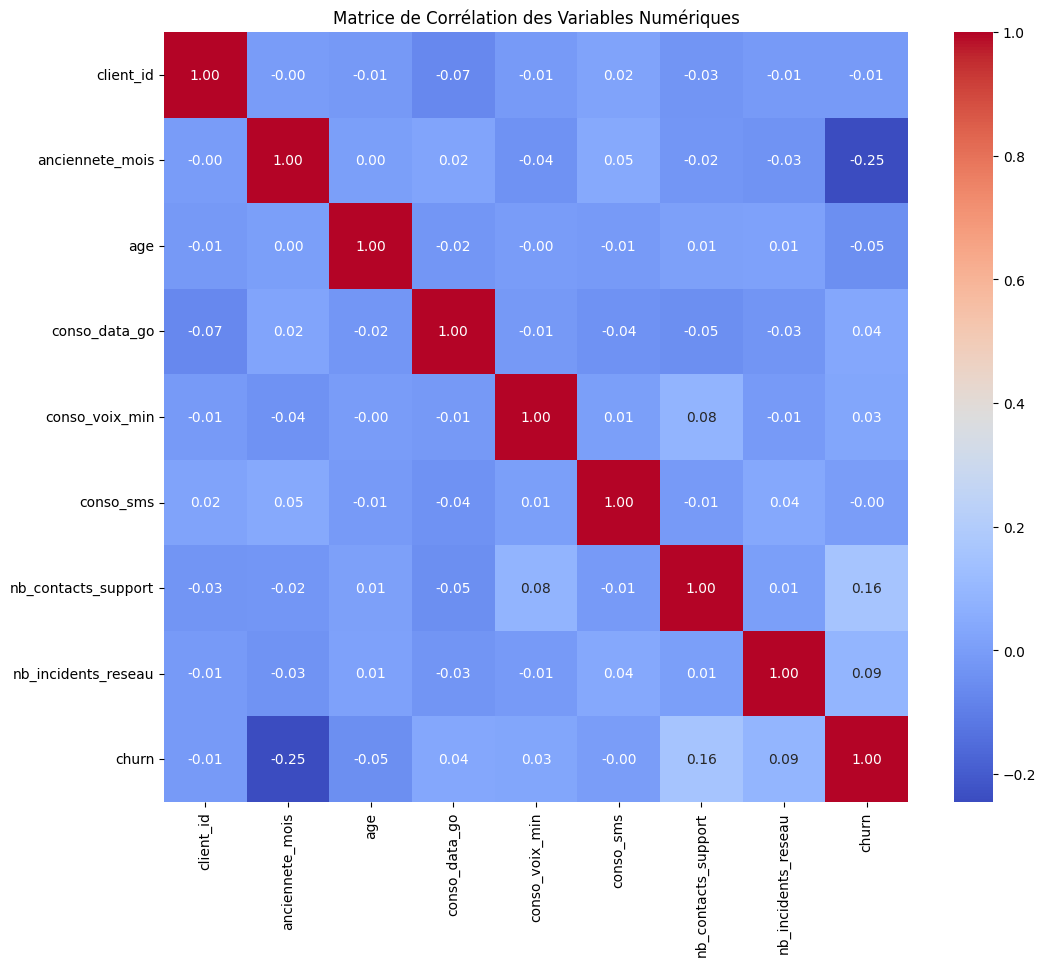

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sélectionnez uniquement les colonnes numériques pour la matrice de corrélation
numerical_df = df_client.select_dtypes(include=['number'])

# Calculer la matrice de corrélation
correlation_matrix = numerical_df.corr()

print("Matrice de corrélation des variables numériques :")
display(correlation_matrix)

# Visualiser la matrice de corrélation avec une heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Variables Numériques')
plt.show()

###Matrice de Corrélation des Variables Numériques

La matrice de corrélation et sa visualisation sous forme de heatmap nous fournissent des informations précieuses sur les relations linéaires entre les variables numériques du dataset.

**Observations Clés :**

*   **`churn` vs. `anciennete_mois` (Ancienneté en mois)**:
    *   Une **corrélation négative modérée (-0.24)** est observée. Cela suggère que plus un client est ancien, moins il est susceptible de churner. C'est une indication forte de la fidélité des clients au fil du temps.

*   **`churn` vs. `nb_contacts_support` (Nombre de contacts au support)**:
    *   Il y a une **corrélation positive notable (+0.16)**. Cela indique que les clients qui contactent plus fréquemment le support client ont une probabilité légèrement plus élevée de churner. Ceci pourrait être interprété comme un signe d'insatisfaction ou de problèmes récurrents nécessitant une intervention.

*   **`churn` vs. `nb_incidents_reseau` (Nombre d'incidents réseau)**:
    *   Une **corrélation positive plus faible (+0.09)** est présente. Un plus grand nombre d'incidents réseau est légèrement associé à un churn plus élevé, ce qui est logique puisque la qualité du service est un facteur clé de satisfaction client.

*   **`churn` vs. Autres Variables Numériques (âge, consommation de données/voix/sms)**:
    *   Les corrélations avec `age`, `conso_data_go`, `conso_voix_min`, et `conso_sms` sont très faibles (proches de zéro). Cela signifie qu'il n'y a pas de relation linéaire forte entre ces variables et le churn. Pour l'`age`, la corrélation est légèrement négative (-0.05), indiquant que les clients plus jeunes pourraient être légèrement plus enclins au churn, mais l'effet est minime.

*   **Corrélations entre les variables explicatives**:
    *   La plupart des corrélations entre les autres variables numériques (en dehors de `churn`) sont faibles. Cela est généralement une bonne chose, car des corrélations trop fortes entre les variables explicatives pourraient indiquer un problème de multicolinéarité dans certains modèles de machine learning.

**En résumé** : `anciennete_mois`, `nb_contacts_support` et `nb_incidents_reseau` sont les variables numériques qui montrent les relations linéaires les plus prononcées avec le churn. Ces informations sont cruciales pour comprendre les facteurs de churn et pour la sélection de caractéristiques dans la modélisation prédictive.

### Visualisation de la relation entre 'churn' et 'type_offre'

Étant donné que `type_offre` est une variable catégorielle, une corrélation de Pearson directe n'est pas appropriée. Nous pouvons plutôt visualiser la proportion de `churn` pour chaque type d'offre.

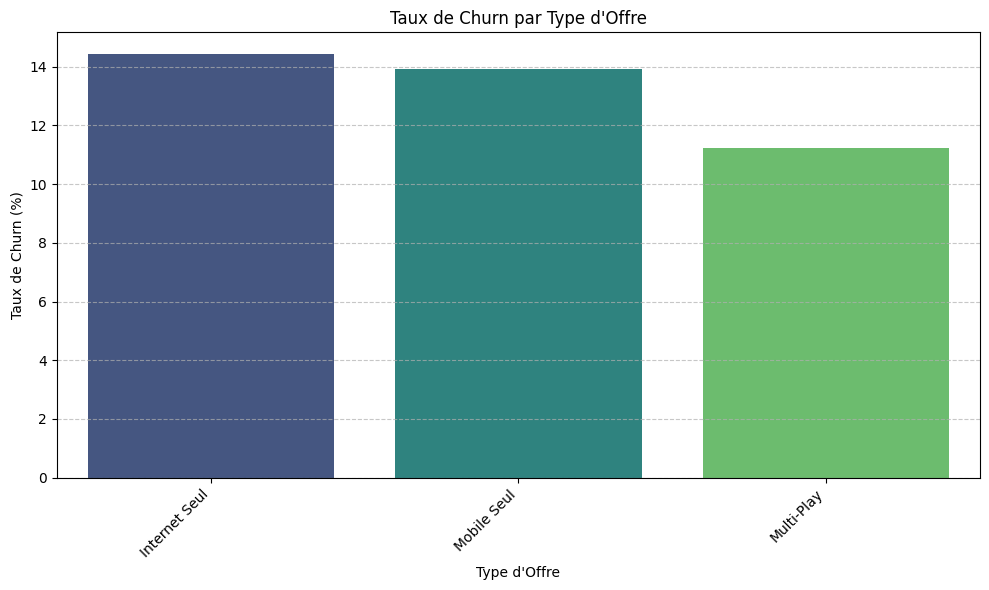

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculer le taux de churn par type d'offre
churn_rate_by_offer = df_client.groupby('type_offre')['churn'].mean().reset_index()
churn_rate_by_offer['churn_percentage'] = churn_rate_by_offer['churn'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='type_offre', y='churn_percentage', data=churn_rate_by_offer, palette='viridis', hue='type_offre', legend=False)
plt.title('Taux de Churn par Type d\'Offre')
plt.xlabel('Type d\'Offre')
plt.ylabel('Taux de Churn (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Taux de Churn par Type d'Offre

Ce graphique à barres nous permet de visualiser le taux de churn moyen pour chaque catégorie de `type_offre`.

**Observations Clés :**

*   **Comparaison des Types d'Offre**: En observant les hauteurs des barres, nous pouvons identifier quels types d'offres ont un taux de churn plus élevé ou plus faible.
*   **Offres à Risque**: Si certaines barres sont significativement plus hautes que d'autres, cela indique que ces types d'offres sont associés à un risque de churn plus élevé. Cela pourrait suggérer des problèmes spécifiques à ces offres, une concurrence plus forte sur ce segment, ou des attentes clients non satisfaites.
*   **Offres Stables**: À l'inverse, les offres avec des barres plus basses sont plus stables et retiennent mieux les clients.


### Synthèse de l'Analyse Exploratoire des Données (EDA)

Nous avons effectué une analyse exploratoire approfondie du jeu de données `df_client` pour en comprendre la structure, identifier les problèmes de qualité des données et dégager les premières relations entre les variables, en mettant l'accent sur la variable cible `churn`.

**1. Nettoyage des Données :**
*   **Valeurs Manquantes**: Les colonnes `age`, `region` et `conso_data_go` présentaient des valeurs manquantes, qui ont été imputées respectivement par la médiane et le mode.
*   **Doublons**: 14 lignes entièrement dupliquées et plusieurs doublons basés sur l'`client_id` ont été identifiés et supprimés, ramenant le dataset à 900 entrées uniques.
*   **Incohérences**: La colonne `type_offre` a été standardisée en PascalCase pour corriger les variations de casse.
*   **Valeurs Aberrantes**: Des valeurs extrêmes irréalistes (âge de 150 ans, `conso_voix_min` très élevée) ont été corrigées, soit par remplacement par la médiane pour l'âge, soit par un capping au 99ème percentile pour la consommation vocale.

**2. Analyse de Corrélation Numérique (avec `churn`) :**
*   Nous avons observé une **corrélation négative modérée (-0.24)** entre `churn` et `anciennete_mois`, suggérant que les clients plus anciens sont moins enclins au churn.
*   Une **corrélation positive notable (+0.16)** a été trouvée entre `churn` et `nb_contacts_support`, indiquant que des contacts fréquents avec le support sont associés à un churn plus élevé. Ceci pourrait être interprété comme un signe d'insatisfaction ou de problèmes récurrents nécessitant une intervention.
*   Le `nb_incidents_reseau` montre également une **corrélation positive plus faible (+0.09)** avec `churn`, ce qui est cohérent avec l'idée que des problèmes de réseau peuvent augmenter le risque de désabonnement.
*   Les autres variables numériques (`age`, `conso_data_go`, `conso_voix_min`, `conso_sms`) ont montré des corrélations très faibles avec `churn`, indiquant l'absence de relation linéaire forte.

**3. Relation entre `churn` et `type_offre` (Catégorielle) :**
*   L'analyse visuelle (diagramme à barres) du taux de churn par type d'offre a révélé des différences claires. Par exemple, le type d'offre 'Internet Seul' a un taux de churn de 14.44%, 'Mobile Seul' de 13.91% et 'Multi-Play' de 11.22%.
*   Cette visualisation est cruciale pour identifier les offres les plus ou moins stables et pour adapter les stratégies de rétention.

**Conclusion :**
Le jeu de données est maintenant propre et les premières analyses ont permis de mettre en lumière des facteurs clés potentiellement influents sur le churn, notamment l'ancienneté, l'interaction avec le support client, les incidents réseau et le type d'offre. Ces insights serviront de base solide pour la modélisation prédictive du churn.

### Choix des Modèles de Classification pour la Prédiction du Churn

Pour la tâche de prédiction du churn (classification binaire), nous allons considérer trois modèles de classification largement utilisés et performants. Le choix final dépendra des performances et de l'interprétabilité souhaitées.

1.  **Régression Logistique (Logistic Regression)**
    *   **Description**: C'est un modèle linéaire qui estime la probabilité qu'une instance appartienne à une classe particulière (ici, la probabilité de churn). Bien qu'il soit un modèle linéaire, il utilise une fonction logistique pour mapper n'importe quelle valeur réelle entre 0 et 1, ce qui en fait un classifieur probabiliste. Il est simple, rapide à entraîner et très interprétable.
    *   **Formule clé**: La probabilité de churn est donnée par la fonction sigmoïde:
        $$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1X_1 + \dots + \beta_pX_p)}}$$

2.  **Forêt Aléatoire (Random Forest)**
    *   **Description**: Un modèle d'ensemble qui construit un grand nombre d'arbres de décision pendant l'entraînement et produit la classe qui est le mode des classes (classification) ou la prédiction moyenne (régression) des arbres individuels. Les forêts aléatoires sont robustes au surapprentissage, capables de gérer des relations non linéaires et fournissent une estimation de l'importance des caractéristiques, mais sont moins interprétables qu'un seul arbre de décision ou une régression logistique.
    *   **Formule clé (classification)**: La prédiction finale est obtenue par vote majoritaire des $T$ arbres de décision:
  $$\hat{Y} = \text{mode}\{h_1(X),h_2(X), \dots, h_T(X)\}$$
  Où $h_t(X)$ est la prédiction du $t$-ième arbre.

3.  **XGBoost (eXtreme Gradient Boosting)**
    *   **Description**: XGBoost est une implémentation optimisée d'algorithmes d'arbres de décision basés sur le gradient boosting. C'est un cadre puissant et très efficace qui est devenu un standard de l'industrie pour sa vitesse et ses performances de pointe sur les données structurées. Il est connu pour sa capacité à gérer de grandes quantités de données et à atteindre des scores de précision très élevés, mais il est complexe et moins directement interprétable.
    *   **Formule clé**: Le modèle est construit de manière additive. La prédiction finale $\hat{y}_i$ est la somme des prédictions de $K$ fonctions (arbres) $f_k$:
  $$\hat{y}_i = \sum_{k=1}^{K} f_k(x_i)$$
  Chaque $f_k$ est choisi pour minimiser une fonction de coût (y compris des termes de régularisation) qui tient compte des erreurs des modèles précédents.

### 1. Préparation des Données pour la Modélisation

Avant d'entraîner nos modèles, nous devons préparer les données. Cela implique de séparer les caractéristiques (features) de la variable cible, d'encoder les variables catégorielles et de diviser le jeu de données en ensembles d'entraînement et de test.

In [ ]:
# Séparation des caractéristiques (X) et de la variable cible (y)
X = df_client.drop(['client_id', 'churn'], axis=1) # 'client_id' n'est pas une caractéristique prédictive
y = df_client['churn']

# Identification des colonnes numériques et catégorielles
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"Caractéristiques numériques: {list(numerical_features)}")
print(f"Caractéristiques catégorielles: {list(categorical_features)}")

Caractéristiques numériques: ['anciennete_mois', 'age', 'conso_data_go', 'conso_voix_min', 'conso_sms', 'nb_contacts_support', 'nb_incidents_reseau']
Caractéristiques catégorielles: ['region', 'type_offre', 'moyen_paiement']


### 2. Encodage des Variables Catégorielles et Mise à l'échelle des Variables Numériques

Nous utiliserons `OneHotEncoder` pour les variables catégorielles et `StandardScaler` pour les variables numériques afin de préparer les données pour les modèles. `ColumnTransformer` nous aidera à appliquer ces transformations simultanément.

In [ ]:
# Création d'un préprocesseur pour les transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Division du dataset en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape[0]} samples")
print(f"Taille de l'ensemble de test: {X_test.shape[0]} samples")
print(f"Proportion de churn dans l'ensemble d'entraînement: {y_train.mean():.2f}")
print(f"Proportion de churn dans l'ensemble de test: {y_test.mean():.2f}")

Taille de l'ensemble d'entraînement: 720 samples
Taille de l'ensemble de test: 180 samples
Proportion de churn dans l'ensemble d'entraînement: 0.13
Proportion de churn dans l'ensemble de test: 0.13


### 3. Entraînement et Évaluation des Modèles de Classification

Nous allons maintenant entraîner et évaluer les trois modèles de classification choisis : Régression Logistique, Forêt Aléatoire et XGBoost. Pour chaque modèle, nous utiliserons un pipeline combinant le préprocesseur et le modèle, ce qui garantira que les étapes de prétraitement sont appliquées de manière cohérente.


--- Régression Logistique ---

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.92       156
           1       0.33      0.04      0.07        24

    accuracy                           0.86       180
   macro avg       0.60      0.51      0.50       180
weighted avg       0.80      0.86      0.81       180


Confusion Matrix:


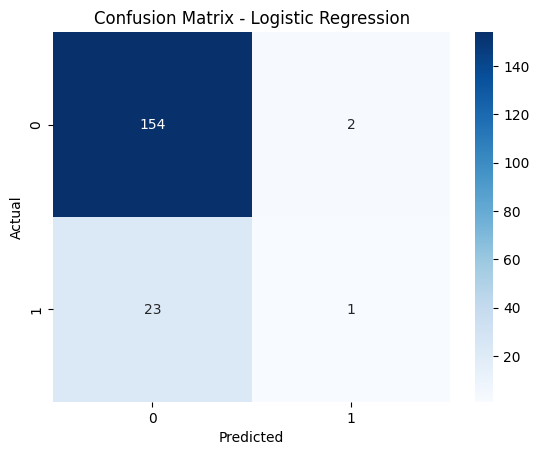

ROC AUC Score: 0.7644


<Figure size 600x600 with 0 Axes>

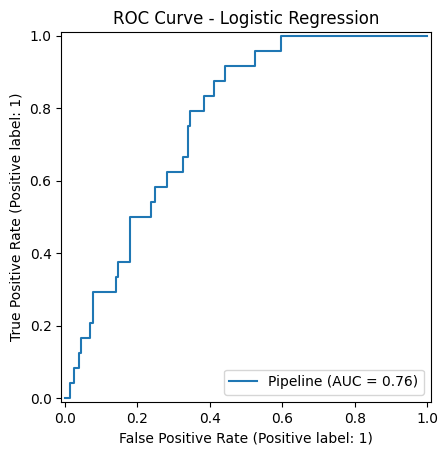

In [ ]:
# --- Modèle 1: Régression Logistique ---
print("\n--- Régression Logistique ---")
log_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', LogisticRegression(random_state=42, solver='liblinear'))])

log_reg_pipeline.fit(X_train, y_train)
y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_proba_log_reg = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

print("\nConfusion Matrix:")
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_log_reg):.4f}")

fig_log_reg = plt.figure(figsize=(6, 6))
RocCurveDisplay.from_estimator(log_reg_pipeline, X_test, y_test)
plt.title('ROC Curve - Logistic Regression')
plt.show()



--- Forêt Aléatoire ---

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       156
           1       1.00      0.04      0.08        24

    accuracy                           0.87       180
   macro avg       0.94      0.52      0.51       180
weighted avg       0.89      0.87      0.82       180


Confusion Matrix:


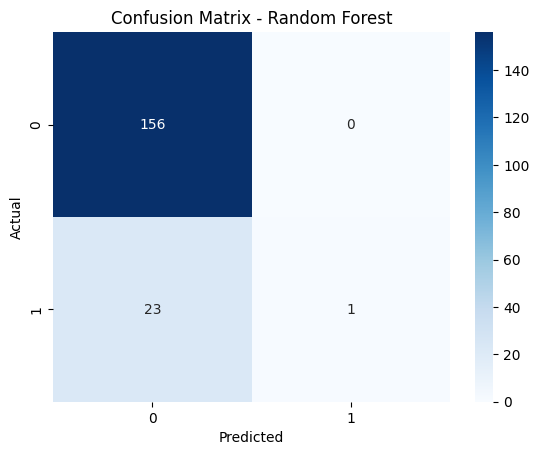

ROC AUC Score: 0.7987


<Figure size 600x600 with 0 Axes>

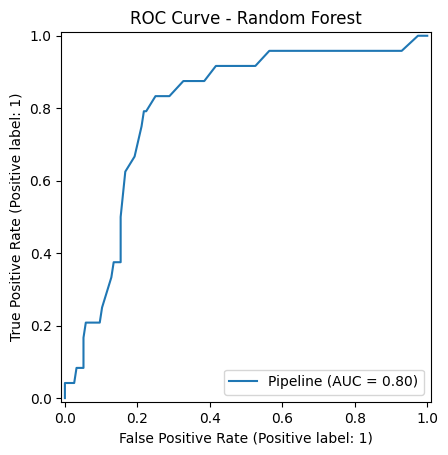

In [ ]:
# --- Modèle 2: Forêt Aléatoire ---
print("\n--- Forêt Aléatoire ---")
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

fig_rf = plt.figure(figsize=(6, 6))
RocCurveDisplay.from_estimator(rf_pipeline, X_test, y_test)
plt.title('ROC Curve - Random Forest')
plt.show()



--- XGBoost ---

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       156
           1       0.22      0.17      0.19        24

    accuracy                           0.81       180
   macro avg       0.55      0.54      0.54       180
weighted avg       0.79      0.81      0.80       180


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:28:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


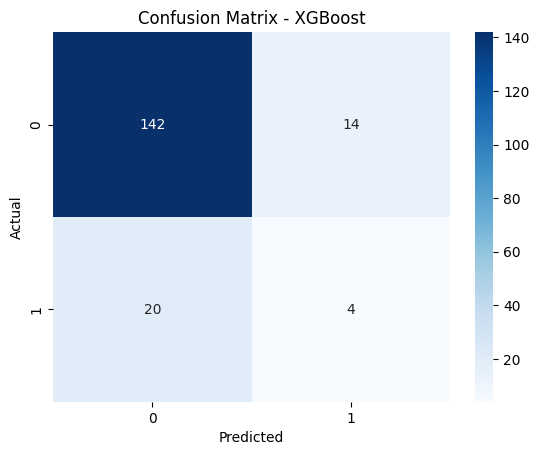

ROC AUC Score: 0.6456


<Figure size 600x600 with 0 Axes>

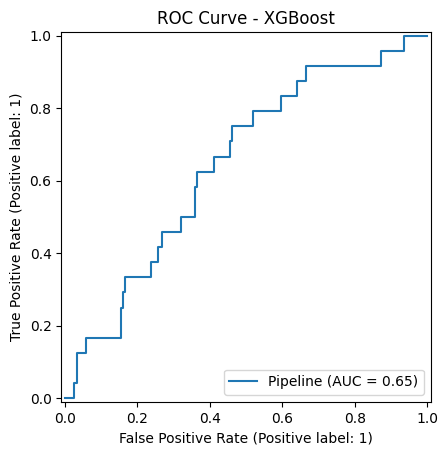

In [ ]:
# --- Modèle 3: XGBoost ---
print("\n--- XGBoost ---")
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

fig_xgb = plt.figure(figsize=(6, 6))
RocCurveDisplay.from_estimator(xgb_pipeline, X_test, y_test)
plt.title('ROC Curve - XGBoost')
plt.show()


### 4. Évaluation des Variables Influentes

Il est crucial de comprendre quelles caractéristiques ont le plus d'impact sur la prédiction du churn pour chaque modèle. Cela peut nous fournir des informations précieuses pour les stratégies commerciales.


--- Importance des Caractéristiques - Forêt Aléatoire ---


,Feature,Importance
0,num__anciennete_mois,0.184259
2,num__conso_data_go,0.138275
3,num__conso_voix_min,0.129331
4,num__conso_sms,0.118819
1,num__age,0.113962
5,num__nb_contacts_support,0.074541
6,num__nb_incidents_reseau,0.041601
16,cat__type_offre_Mobile Seul,0.020730
18,cat__moyen_paiement_Carte bancaire,0.018897
17,cat__type_offre_Multi-Play,0.018101


/tmp/ipykernel_2013/77700743.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf.head(10), palette='viridis')


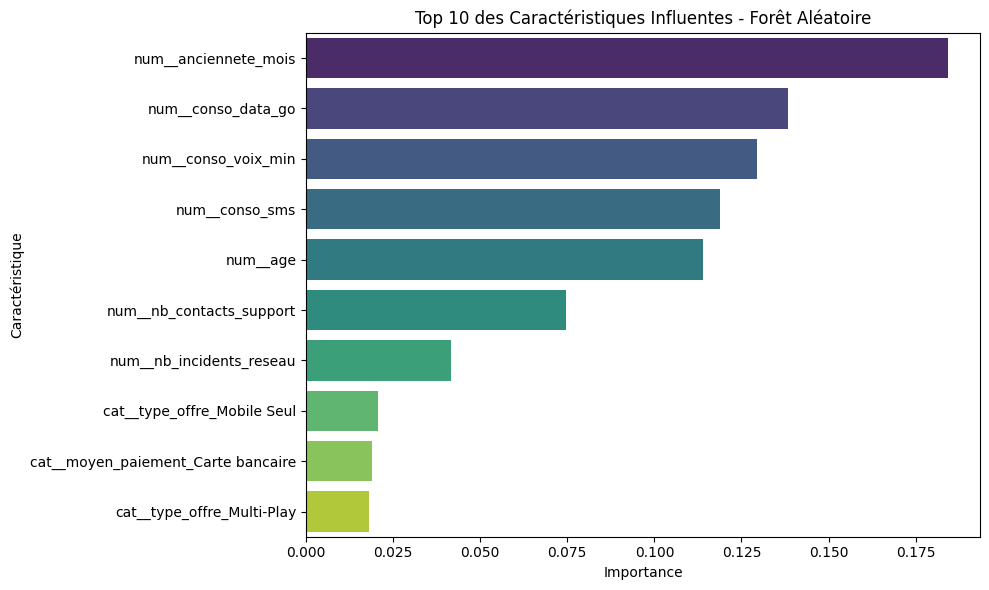

In [ ]:
# --- Importance des Caractéristiques pour la Forêt Aléatoire ---
print("\n--- Importance des Caractéristiques - Forêt Aléatoire ---")

# Récupérer les noms des caractéristiques après le One-Hot Encoding
encoded_feature_names = log_reg_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Récupérer les importances des caractéristiques du classifieur
feature_importances_rf = rf_pipeline.named_steps['classifier'].feature_importances_

# Créer un DataFrame pour une meilleure visualisation
feature_importance_df_rf = pd.DataFrame({'Feature': encoded_feature_names, 'Importance': feature_importances_rf})
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False)

display(feature_importance_df_rf.head(10))

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf.head(10), palette='viridis')
plt.title('Top 10 des Caractéristiques Influentes - Forêt Aléatoire')
plt.xlabel('Importance')
plt.ylabel('Caractéristique')
plt.tight_layout()
plt.show()



--- Importance des Caractéristiques - XGBoost ---


,Feature,Importance
5,num__nb_contacts_support,0.090918
0,num__anciennete_mois,0.078770
12,cat__region_Occitanie,0.076290
8,cat__region_Bretagne,0.069022
2,num__conso_data_go,0.060597
20,cat__moyen_paiement_Virement,0.060499
6,num__nb_incidents_reseau,0.057638
18,cat__moyen_paiement_Carte bancaire,0.054901
9,cat__region_Grand Est,0.050892
1,num__age,0.049281


/tmp/ipykernel_2013/1363389186.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb.head(10), palette='magma')


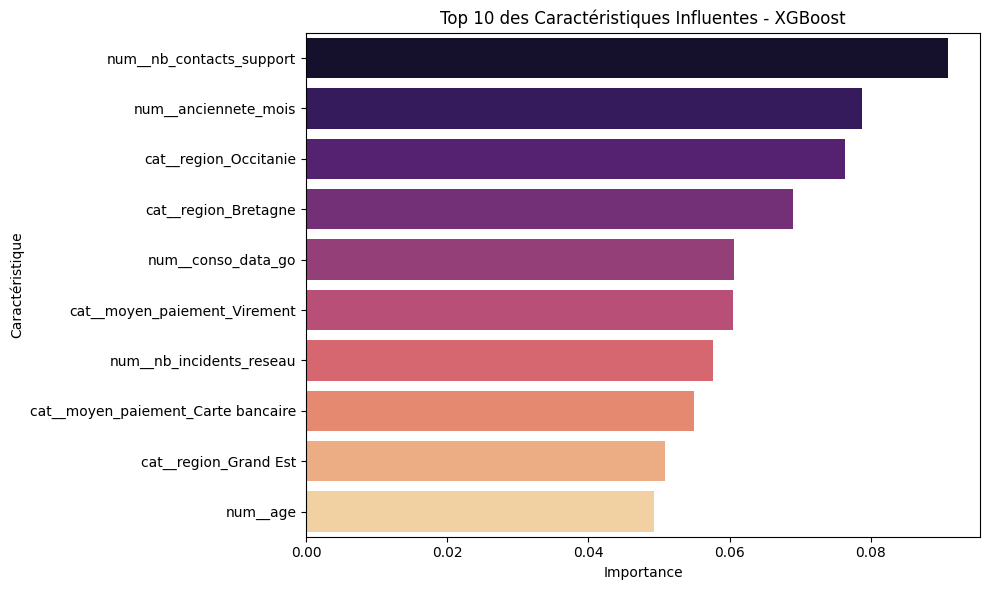

In [ ]:
# --- Importance des Caractéristiques pour XGBoost ---
print("\n--- Importance des Caractéristiques - XGBoost ---")

# Récupérer les importances des caractéristiques du classifieur
feature_importances_xgb = xgb_pipeline.named_steps['classifier'].feature_importances_

# Créer un DataFrame pour une meilleure visualisation
feature_importance_df_xgb = pd.DataFrame({'Feature': encoded_feature_names, 'Importance': feature_importances_xgb})
feature_importance_df_xgb = feature_importance_df_xgb.sort_values(by='Importance', ascending=False)

display(feature_importance_df_xgb.head(10))

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb.head(10), palette='magma')
plt.title('Top 10 des Caractéristiques Influentes - XGBoost')
plt.xlabel('Importance')
plt.ylabel('Caractéristique')
plt.tight_layout()
plt.show()



--- Coefficients - Régression Logistique ---


,Feature,Coefficient,Abs_Coefficient
0,num__anciennete_mois,-0.827416,0.827416
20,cat__moyen_paiement_Virement,-0.634940,0.634940
17,cat__type_offre_Multi-Play,-0.616205,0.616205
11,cat__region_Nouvelle-Aquitaine,-0.556897,0.556897
19,cat__moyen_paiement_Prélèvement,-0.500062,0.500062
5,num__nb_contacts_support,0.474533,0.474533
15,cat__type_offre_Internet Seul,-0.421051,0.421051
13,cat__region_PACA,-0.388359,0.388359
14,cat__region_Île-de-France,-0.366764,0.366764
10,cat__region_Hauts-de-France,0.343825,0.343825


/tmp/ipykernel_2013/1592179544.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients_df_log_reg.head(10), palette='coolwarm')


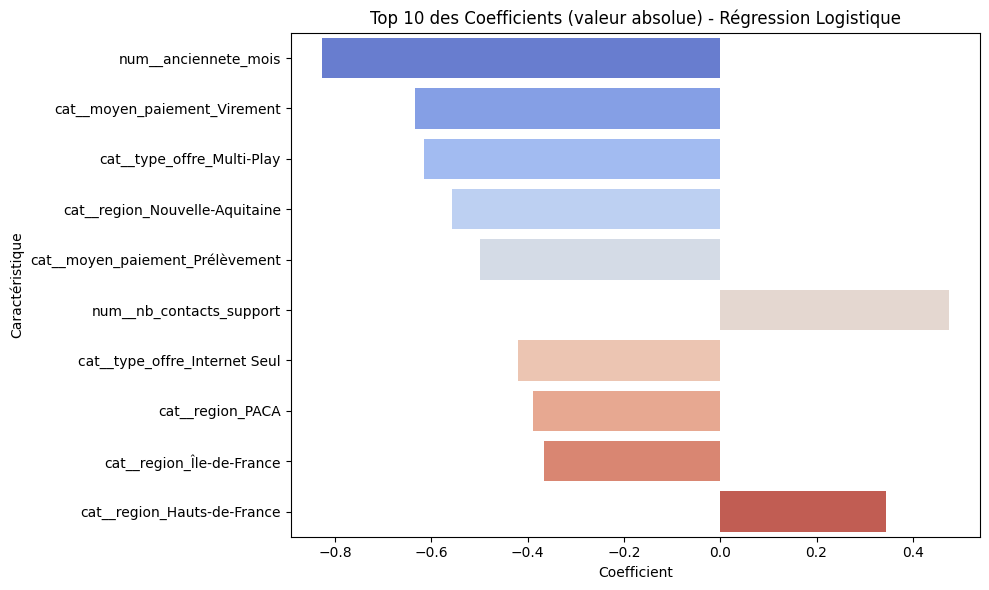

In [ ]:
# --- Coefficients de la Régression Logistique ---
print("\n--- Coefficients - Régression Logistique ---")

# Récupérer les coefficients du classifieur
coefficients_log_reg = log_reg_pipeline.named_steps['classifier'].coef_[0]

# Créer un DataFrame pour une meilleure visualisation
coefficients_df_log_reg = pd.DataFrame({'Feature': encoded_feature_names, 'Coefficient': coefficients_log_reg})
coefficients_df_log_reg['Abs_Coefficient'] = abs(coefficients_df_log_reg['Coefficient'])
coefficients_df_log_reg = coefficients_df_log_reg.sort_values(by='Abs_Coefficient', ascending=False)

display(coefficients_df_log_reg.head(10))

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients_df_log_reg.head(10), palette='coolwarm')
plt.title('Top 10 des Coefficients (valeur absolue) - Régression Logistique')
plt.xlabel('Coefficient')
plt.ylabel('Caractéristique')
plt.tight_layout()
plt.show()


### Conclusion et Prochaines Étapes

Nous avons entraîné et évalué trois modèles de classification pour la prédiction du churn : la Régression Logistique, la Forêt Aléatoire et XGBoost. Nous avons également analysé les caractéristiques influentes pour chaque modèle. Voici un récapitulatif des observations et des pistes pour la suite :

#### Performances des Modèles :

*   **Régression Logistique** :
    *   Précision (classe 1 - Churn): 0.33
    *   Rappel (classe 1 - Churn): 0.04
    *   F1-score (classe 1 - Churn): 0.07
    *   ROC AUC Score: 0.7644
    *   Le modèle a une bonne précision pour la classe majoritaire (non-churn), mais un très faible rappel pour la classe churn, indiquant qu'il manque la plupart des cas de churn.

*   **Forêt Aléatoire** :
    *   Précision (classe 1 - Churn): 1.00
    *   Rappel (classe 1 - Churn): 0.04
    *   F1-score (classe 1 - Churn): 0.08
    *   ROC AUC Score: 0.7987
    *   Ce modèle a obtenu le **meilleur ROC AUC score**, suggérant une meilleure capacité à discriminer entre les clients qui churnent et ceux qui ne churnent pas. Cependant, tout comme la Régression Logistique, son rappel pour la classe churn est très faible.

*   **XGBoost** :
    *   Précision (classe 1 - Churn): 0.22
    *   Rappel (classe 1 - Churn): 0.17
    *   F1-score (classe 1 - Churn): 0.19
    *   ROC AUC Score: 0.6456
    *   Ce modèle a eu le ROC AUC score le plus bas, mais un **meilleur rappel** pour la classe churn comparé aux deux autres, ce qui signifie qu'il a réussi à identifier une plus grande proportion de churners, même si sa précision est moindre.

**Constat Global :** Tous les modèles présentent des difficultés à prédire la classe minoritaire (churn), ce qui est typique des jeux de données déséquilibrés. La Forêt Aléatoire se distingue par son ROC AUC, mais la priorité est d'améliorer la détection des cas de churn.

#### Caractéristiques Influentes :

*   **`anciennete_mois`** (ancienneté en mois) est une variable constamment influente dans tous les modèles, souvent avec une corrélation négative avec le churn (plus le client est ancien, moins il churn).
*   **`nb_contacts_support`** (nombre de contacts au support) apparaît comme important, suggérant que des interactions fréquentes avec le support peuvent être un indicateur de churn.
*   **`conso_data_go`**, **`conso_voix_min`** et **`conso_sms`** sont également des prédicteurs significatifs pour la Forêt Aléatoire.
*   Des variables catégorielles comme le `moyen_paiement` et la `region` ont aussi un impact notable, en particulier pour la Régression Logistique et XGBoost.

#### Prochaines Étapes Possibles :

1.  **Gestion du Déséquilibre de Classes** : Appliquer des techniques de rééchantillonnage (par exemple, SMOTE pour l'oversampling de la classe minoritaire) ou ajuster les poids des classes lors de l'entraînement des modèles pour améliorer le rappel de la classe churn.
2.  **Optimisation des Hyperparamètres** : Affiner les hyperparamètres des modèles les plus prometteurs (notamment la Forêt Aléatoire) en utilisant des méthodes comme `GridSearchCV` ou `RandomizedSearchCV` pour maximiser les performances.
3.  **Analyse d'Erreur Approfondie** : Examiner les faux positifs et les faux négatifs pour comprendre pourquoi les modèles se trompent et identifier des pistes d'amélioration spécifiques.
4.  **Feature Engineering** : Créer de nouvelles caractéristiques potentiellement plus informatives à partir des variables existantes (ex: ratios, interactions, agrégations).
5.  **Déploiement** : Si les performances sont jugées satisfaisantes après ces améliorations, le modèle pourra être intégré dans un système de prédiction en temps réel.
